<a href="https://colab.research.google.com/github/mta-phy/5820x/blob/main/HWs/Project-1%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="text-align: center;">

# Project 1  
### *MSE 5820x: Data Analytics and Machine Learning in Materials Research*

</div>


## **Used Dataset: LIG Resistnace Data**

## *Data Extraction*
Data are extract from git-hub repository. The dataset of laser-induced graphene (LIG) parameters was extracted using the following code from an Excel file, specifically focusing on variables like laser power, speed, and DPI. It then converts these individual columns into NumPy arrays and displays the first five rows to verify the LIG’s electrical properties, such as sheet resistance and conductance.


In [2]:
import pandas as pd
import numpy as np
url = 'https://github.com/mta-phy/5820x/raw/main/HWs/LIG.xlsx'
Data = pd.read_excel(url)
Power = Data.iloc[:, 0].to_numpy();
Speed = Data.iloc[:, 1].to_numpy();
DPI = Data.iloc[:, 2].to_numpy();
Defocus = Data.iloc[:, 3].to_numpy();
Sheet_resistance= Data.iloc[:, 4].to_numpy();
Data.head(5)

,Power (W),Speed (cm/s),DPI,Defocus (inch),Sheet Resistance (ohm)
0,58,19,400,-0.1,7.1757
1,60,18,200,0.2,7.1757
2,50,17,600,-0.1,8.8641
3,56,18,300,-0.1,10.9746
4,55,16,400,-0.2,11.3967


## *Statistical Breakdown*
The output of the following code provides a statistical breakdown of 104 samples, highlighting some extreme variability in your material properties.


In [2]:
Data.describe().round(4)

,Power (W),Speed (cm/s),DPI,Defocus (inch),Sheet Resistance (ohm),Sheet Conductance (1/ohm)
count,104.0000,104.0000,104.0000,104.0000,1.040000e+02,104.0000
mean,50.5288,21.5385,369.9519,0.0394,4.302204e+06,0.0345
std,12.4845,7.8739,164.4858,0.1573,8.421074e+06,0.0312
min,10.0000,10.0000,75.0000,-0.3000,7.175700e+00,0.0000
25%,45.0000,16.0000,300.0000,-0.1000,1.762270e+01,0.0092
50%,52.5000,20.0000,300.0000,0.0000,3.651160e+01,0.0274
75%,59.0000,25.0000,400.0000,0.2000,1.090073e+02,0.0568
max,70.0000,49.0000,1200.0000,0.3000,2.110500e+07,0.1394


## *Probability Density*
These plots show the probability density distributions for the laser parameters and the resulting electrical properties of the graphene. While Lasing Power and Speed follow roughly normal distributions, the Sheet Resistance is heavily bimodal and skewed, with a large cluster of low-resistance samples and a smaller group of extremely high-resistance outliers.
Consequently, the Sheet Conductance distribution is more spread out and right-skewed, indicating that most experimental trials resulted in relatively low conductance with only a few highly efficient samples.


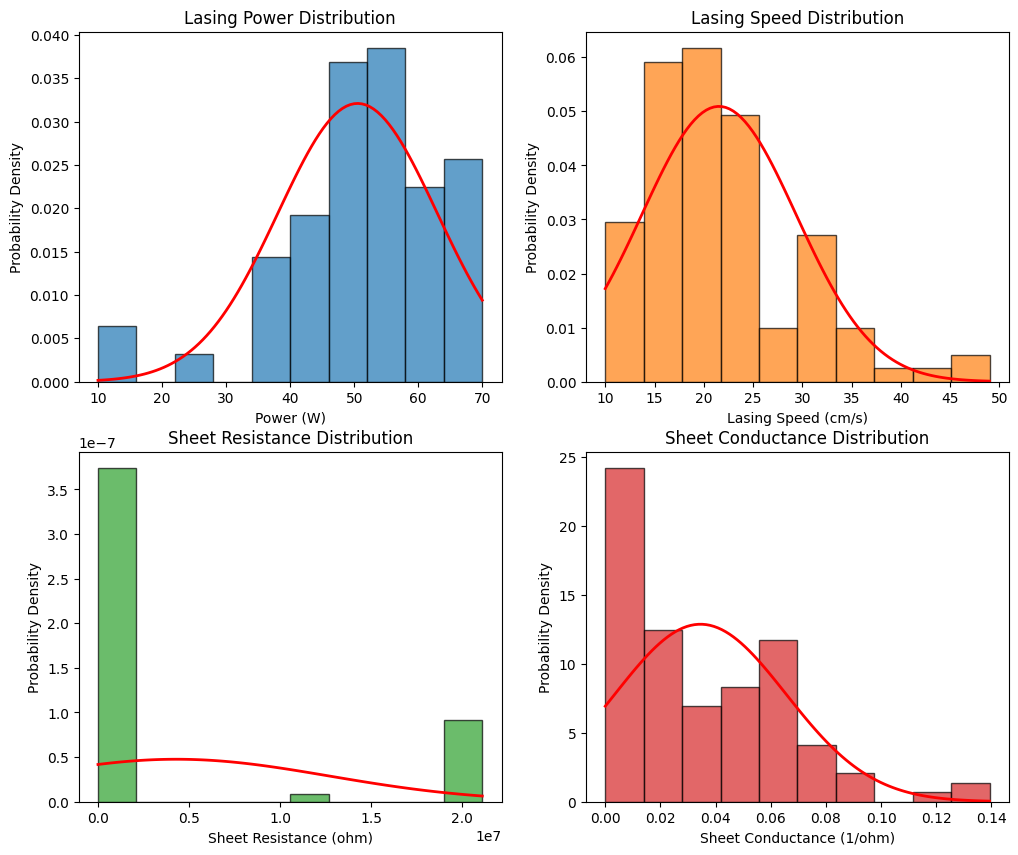

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def gaussian(x, loc, s):
    return (1 / np.sqrt(2 * np.pi * s ** 2) * np.exp(-(x - loc) ** 2 / (2 * s ** 2)))

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(Power, bins=10, density=True, alpha=0.7, color='C0', edgecolor='black')
x0_range = np.linspace(Power.min(), Power.max(), 100)
y0_values = gaussian(x0_range, Power.mean(), Power.std())
plt.plot(x0_range, y0_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Power (W)")
plt.ylabel("Probability Density")
plt.title("Lasing Power Distribution")

plt.subplot(2, 2, 2)
plt.hist(Speed, bins=10, density=True, alpha=0.7, color='C1', edgecolor='black')
x1_range = np.linspace(Speed.min(), Speed.max(), 100)
y1_values = gaussian(x1_range, Speed.mean(), Speed.std())
plt.plot(x1_range, y1_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Lasing Speed (cm/s)")
plt.ylabel("Probability Density")
plt.title("Lasing Speed Distribution")

plt.subplot(2, 2, 3)
plt.hist(Sheet_resistance, bins=10, density=True, alpha=0.7, color='C2', edgecolor='black')
x2_range = np.linspace(Sheet_resistance.min(), Sheet_resistance.max(), 100)
y2_values = gaussian(x2_range, Sheet_resistance.mean(), Sheet_resistance.std())
plt.plot(x2_range, y2_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Sheet Resistance (ohm)")
plt.ylabel("Probability Density")
plt.title("Sheet Resistance Distribution")

plt.subplot(2, 2, 4)
plt.hist(Sheet_conductance, bins=10, density=True, alpha=0.7, color='C3', edgecolor='black')
x3_range = np.linspace(Sheet_conductance.min(), Sheet_conductance.max(), 100)
y3_values = gaussian(x3_range, Sheet_conductance.mean(), Sheet_conductance.std())
plt.plot(x3_range, y3_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Sheet Conductance (1/ohm)")
plt.ylabel("Probability Density")
plt.title("Sheet Conductance Distribution")

plt.show()

## *Pairplot*
The pair plot (or corner plot) visualizes the multidimensional relationships and distributions between laser processing parameters and the resulting graphene properties, categorized by DPI.
Scatter plots show how variables like Power and Speed interact to influence Sheet Conductance; clusters indicate specific power-speed combinations that yield higher conductivity. Color coding reveals that different DPI levels (from 200 to 1200) shift the distributions, particularly in the Defocus and Conductance plots, suggesting pixel density is a significant factor in material quality.

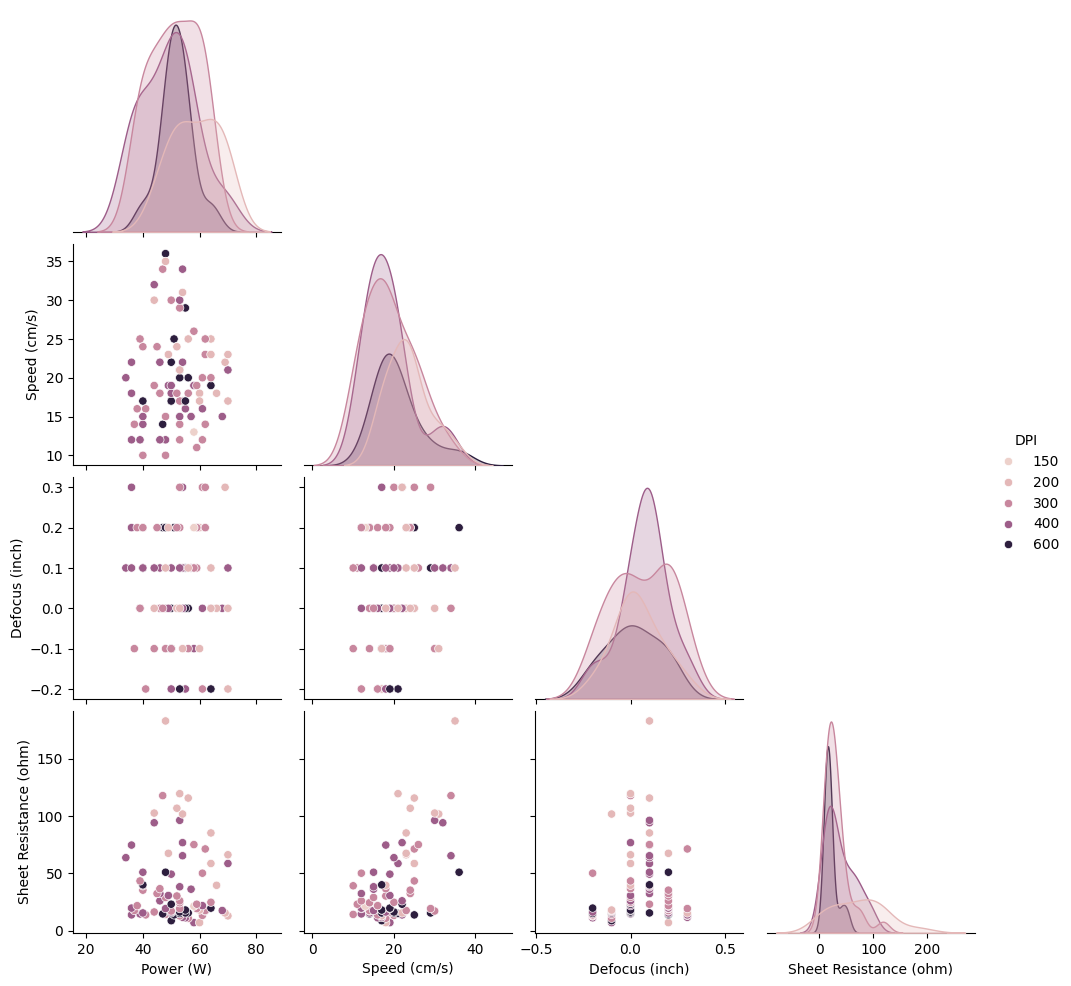

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to visualize
cols = ["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)",
        "Sheet Resistance (ohm)"]

sns.pairplot(Data[cols], diag_kind="kde", corner=True, hue="DPI")
plt.show()

## *Violin Plot*
The violin plot shows how sheet conductance is distributed at each DPI setting.
Each “violin” represents the full density of conductance values, while the box inside shows the median and interquartile range. Several DPI levels display wide, spread‑out violins, indicating large variability in conductance, whereas others show tighter, more compact distributions. the highest conductance values appear at DPI = 200-600.
These settings show taller violins and higher median lines compared with the others.
Lower DPI values such as 75 and 150 cluster toward the bottom, indicating weaker conductance.
Overall, mid‑to‑high DPI levels tend to produce stronger conductance distributions.

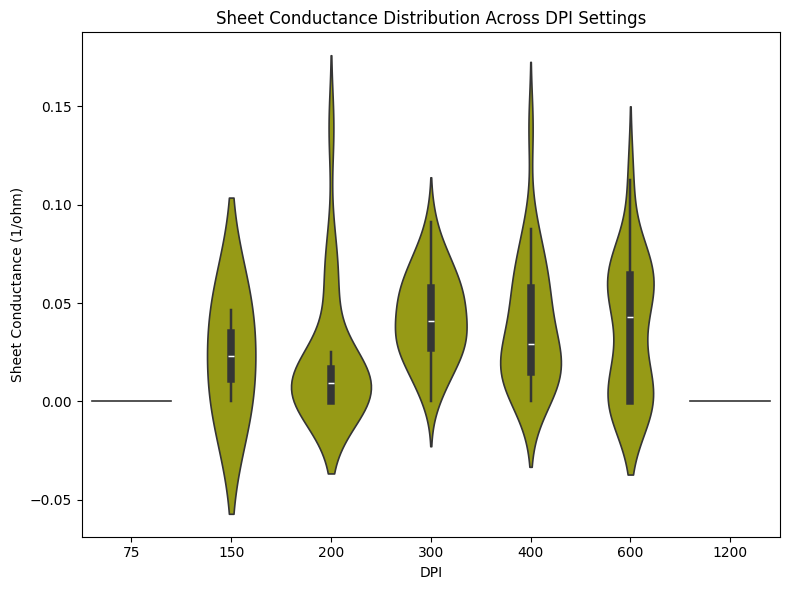

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=Data,
    x="DPI",
    y="Sheet Conductance (1/ohm)",
    inner="box",
    linewidth=1.2,
    color="#AAB000"
)

plt.title("Sheet Conductance Distribution Across DPI Settings")
plt.tight_layout()
plt.show()


## *Three Variable Scattered Relation*
The Power vs Speed plot shows a central cluster of high conductance (red/green) typically between 50W–65W and 15–20 cm/s. In the Power vs DPI and Speed vs DPI plots, the highest conductance values appear concentrated around 300–400 DPI. he Power vs Defocus plot indicates that the most conductive samples occur within a narrow window of defocus (near -0.1 to 0.1). Deviating too far from the focal plane disperses the laser energy, leading to the blue/purple low-conductance results.

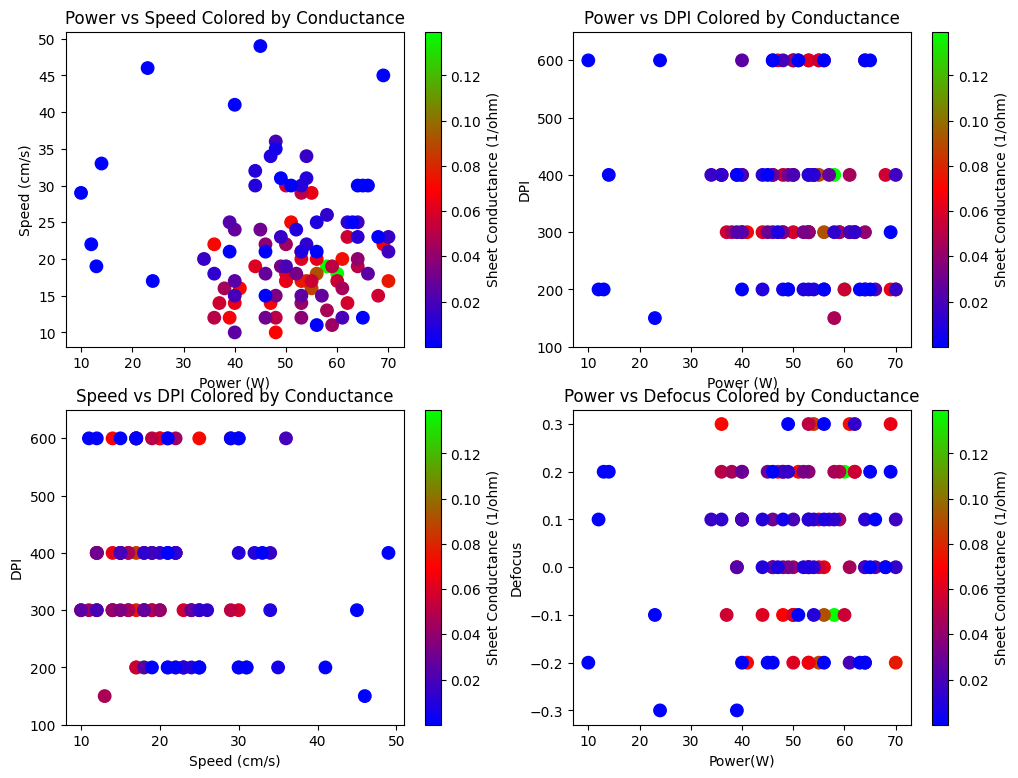

In [6]:
plt.figure(figsize=(12,9))
plt.subplot(2,2,1)
plt.scatter(Power, Speed, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power (W)')
plt.ylabel('Speed (cm/s)')
plt.title('Power vs Speed Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,2)
plt.scatter(Power, DPI, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power (W)')
plt.ylabel('DPI')
plt.ylim(100, 650)
plt.title('Power vs DPI Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,3)
plt.scatter(Speed, DPI, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Speed (cm/s)')
plt.ylabel('DPI')
plt.ylim(100, 650)
plt.title('Speed vs DPI Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,4)
plt.scatter(Power, Defocus, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power(W)')
plt.ylabel('Defocus')
#plt.ylim(100, 650)
plt.title('Power vs Defocus Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.show()


## *Four Variable Scattered Relation*
The figure presents a 3D scatter plot where DPI, Speed, and Power form the three spatial axes, and each point is colored according to its sheet conductance value. Warmer colors indicate higher conductance, while cooler colors represent lower conductance. The distribution of colors across the parameter space highlights regions where conductance tends to increase or decrease. This visualization makes it possible to see how combinations of processing parameters influence electrical performance. Overall, the plot provides a multidimensional view of how conductance responds to changes in laser settings.

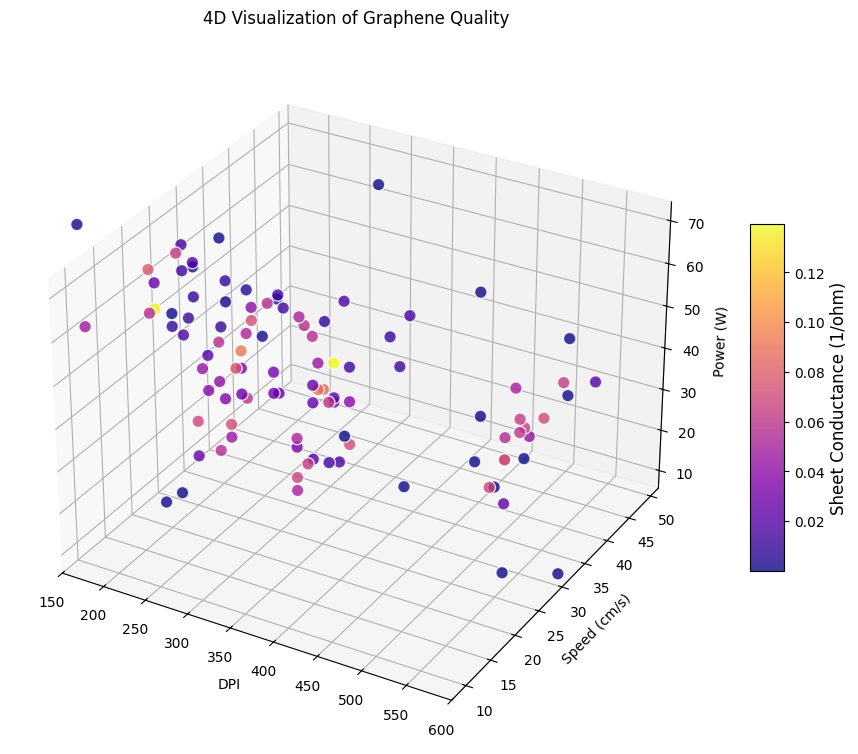

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(DPI, Speed, Power,
                 c=Sheet_conductance,
                 cmap='plasma',
                 s=80,
                 edgecolor='w',
                 alpha=0.8)

# Add a colorbar to decode the 4th dimension
cbar = fig.colorbar(img, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Sheet Conductance (1/ohm)', fontsize=12)

ax.set_xlim(150, 600)


ax.set_xlabel('DPI')
ax.set_ylabel('Speed (cm/s)')
ax.set_zlabel('Power (W)')
ax.set_title('4D Visualization of Graphene Quality', pad=20)

plt.show()

## *% Contributions*
The pie chart summarizes how much each processing parameter contributes to predicting sheet conductance in the Random Forest model.
Speed accounts for the largest share of influence, indicating that changes in scanning speed have the strongest impact on conductance. Power and defocus follow with moderate contributions, showing that both parameters meaningfully shape the energy delivered to the material. DPI has the smallest share, suggesting that line density plays a comparatively minor role in determining conductance.

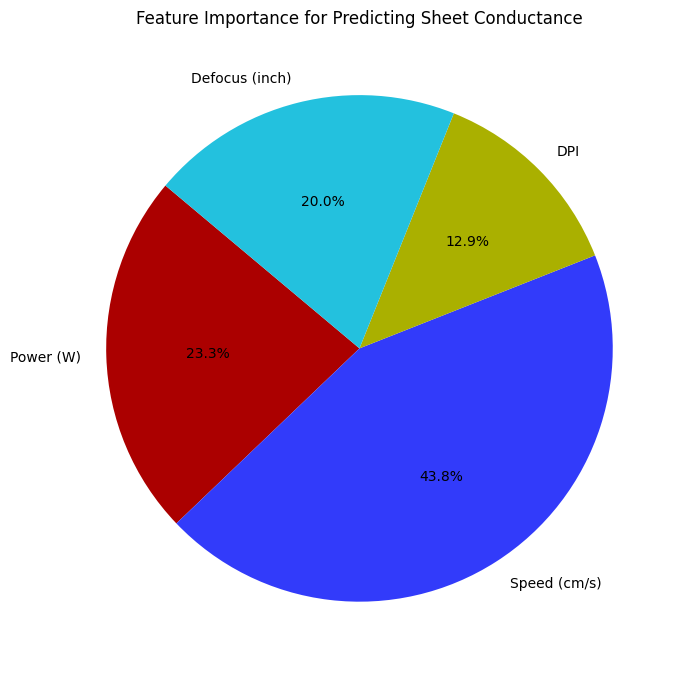

In [8]:
from sklearn.ensemble import RandomForestRegressor

X = Data[["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)"]]
y = Data["Sheet Resistance (ohm)"]

rf = RandomForestRegressor(n_estimators=500, random_state=0)
rf.fit(X, y)

labels = X.columns
sizes = rf.feature_importances_

plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#AB0000", "#323BFA", "#AAB000", "#23C1DE"]
)
plt.title("Feature Importance for Predicting Sheet Conductance")
plt.tight_layout()
plt.show()


## *Correlation Matrix*
The correlation coefficient ranges from -1 to +1, where +1 is a perfect positive relationship, -1 is a perfect negative relationship, and 0 indicates no linear relationship. The correlation between Index 4 (Resistance) and Index 5 (Conductance) is -0.5714. Hence, as resistance increases, conductance must decrease. There is a notable negative correlation (-0.4322) between Speed and Conductance; meaning higher speeds tend to result in lower conductance (and higher resistance, at 0.3831). This suggests that when the laser moves faster, it may be delivering less energy per unit area, leading to less efficient material transformation. Power shows a weak negative correlation with Resistance (-0.2456) and a weak positive correlation with Conductance (0.1914). DPI and Defocus show very low correlation values (mostly near 0 or < 0.2) with the electrical properties.

In [5]:
cor = np.corrcoef(Data.iloc[:, 0:5], rowvar=False)


print("Correlation Matrix:\n", cor)

Correlation Matrix:
 [[ 1.          0.04890756 -0.20855802 -0.08558079 -0.04752407]
 [ 0.04890756  1.         -0.05030091  0.11866337  0.58790242]
 [-0.20855802 -0.05030091  1.         -0.07663646 -0.3527643 ]
 [-0.08558079  0.11866337 -0.07663646  1.          0.06047956]
 [-0.04752407  0.58790242 -0.3527643   0.06047956  1.        ]]


## *Heatmap*
The heatmap visualizes how strongly each pair of variables is linearly related, using both color and numerical correlation values.  Speed shows moderate correlations with both electrical properties, increasing resistance and decreasing conductance as it rises. Most other parameter pairs display weak correlations.

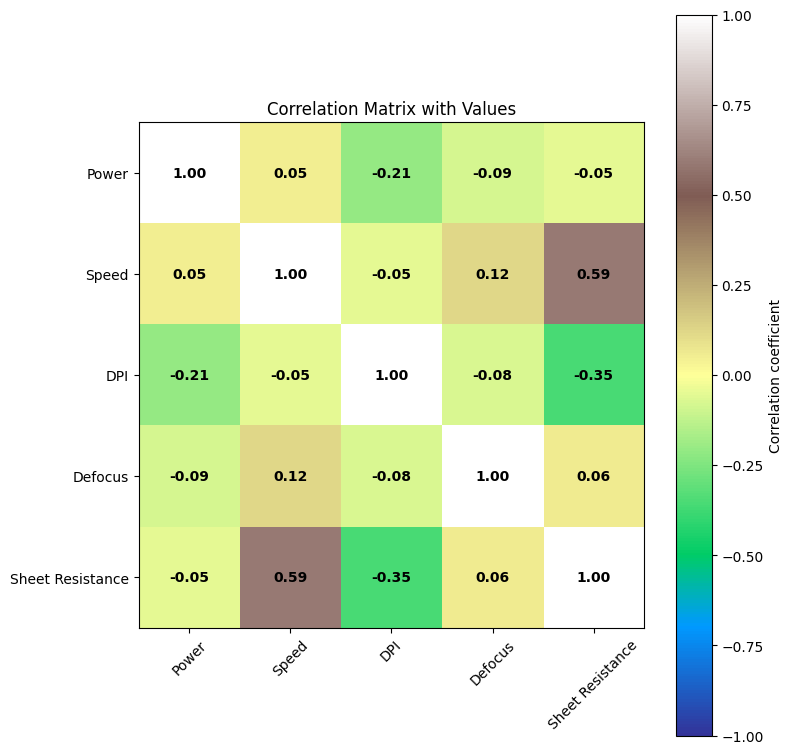

In [7]:
plt.figure(figsize=(8,8))
feature_names=['Power','Speed','DPI','Defocus','Sheet Resistance']

# Create the heatmap
cor = np.corrcoef(Data.iloc[:, 0:5], rowvar=False)
im = plt.imshow(cor, vmin=-1, vmax=1, cmap='terrain')
plt.colorbar(im, label="Correlation coefficient")

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
            text = plt.text(j, i, f"{cor[i, j]:.2f}",
                       ha="center", va="center", color="black",
                       fontweight='bold')


plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Correlation Matrix with Values")
plt.tight_layout()
plt.show()